In [2]:
import os
import sys
import pandas as pd
sys.path.append('..')
from unstructured.staging.base import elements_from_json
from langchain_core.documents import Document
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from openai import OpenAI
from sentence_transformers import SentenceTransformer, util
import numpy as np

import torch
from bert_score import BERTScorer

import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import get_project_path

In [ ]:
data = pd.read_csv(os.path.join(get_project_path(), "data", "openai_new_save.csv"))   

In [ ]:
generated = data["RAG_Ответ"].replace(np.NaN, "No")
references = data['Right answer\xa0'].replace(np.NaN, "No")

references = [ref.replace("\n", " ").strip() for ref in references]
generated = [pred.replace("\n", " ").strip() for pred in generated]

## Accuracy

In [ ]:
def classify_responses(data_q, data_c, data_m):

    classifications = []

    openai_api_key = os.environ["OPENAI_API_KEY"]
    openai_api_base = os.environ["OPENAI_API_BASE"]
    

    for question, correct_answer, model_answer in zip(data_q, data_c, data_m):
        prompt = f"Question: {question}\n\n" \
                 f"The reference response: {correct_answer}\n\n" \
                 f"The model's response: {model_answer}\n\n" \
                 "Evaluate whether the model answered the question correctly. Evaluate not the exact 100% match of the answer with the reference, but rather the correctness of the answer to the question in comparison with the reference (1 is correct, 0 is incorrect)." \
                 "Answer only with a number."

        try:
            openai_client = OpenAI(
                base_url=openai_api_base
                )

            response = openai_client.chat.completions.create(
                model="openai/gpt-4o-2024-11-20",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.2,
                max_tokens=4096
            )
            classification = int(response.choices[0].message.content.strip())
            classifications.append(classification)

        except Exception as e:
            print(f"Ошибка: {e}")
            classifications.append(0)  # Если ошибка, считаем, что ответ неверный

    return classifications

ans = classify_responses(data["Request"], data["The model's response"], data["openai/gpt-4-turbo"])

0.7407407407407407

## BERTScore

In [ ]:
scorer = BERTScorer(model_type="bert-base-multilingual-cased", lang="ru")
P, R, F1 = scorer.score(generated, references)
print(torch.mean(F1))
print(f"prec:{P}, reacall: {R}, f1: {F1}", sep="\n")

tensor(0.6813)
prec:tensor([0.6579, 0.5909, 0.6734, 0.6853, 0.6687, 0.6607, 0.6626, 0.6515, 0.6632,
        0.6542, 0.6611, 0.6521, 0.6687, 0.6764, 0.6696, 0.6651, 0.6951, 0.6790,
        0.7095, 0.6831, 0.6904, 0.6667, 0.6843, 0.6983, 0.6987, 0.6702, 0.6975,
        0.6889, 0.6412, 0.6855, 0.6828, 0.6436, 0.7057, 0.6873, 0.6803, 0.6756,
        0.7001, 0.6906, 0.7066, 0.7113, 0.6787, 0.7034, 0.6528, 0.6655, 0.6902,
        0.6890, 0.6906, 0.6863, 0.6842, 0.6734, 0.6554, 0.6864, 0.6745, 0.6636,
        0.6975, 0.6628, 0.6972, 0.6944, 0.6834, 0.6890, 0.6913, 0.6786, 0.6590,
        0.6737, 0.6958, 0.6907, 0.6797, 0.6607, 0.6729, 0.6818, 0.6846, 0.7186,
        0.6949, 0.6760, 0.6898, 0.7149, 0.7180, 0.6931, 0.6798, 0.7117, 0.6863,
        0.6835, 0.6931, 0.6793, 0.6935, 0.6392, 0.7397, 0.6854, 0.6866, 0.6681,
        0.7143, 0.7366, 0.7263, 0.6955, 0.6864, 0.6949, 0.6633, 0.6755, 0.4270,
        0.6923, 0.6567, 0.6916, 0.6905, 0.6943, 0.7025, 0.6979, 0.6792, 0.6916,
        0.6907, 0.71

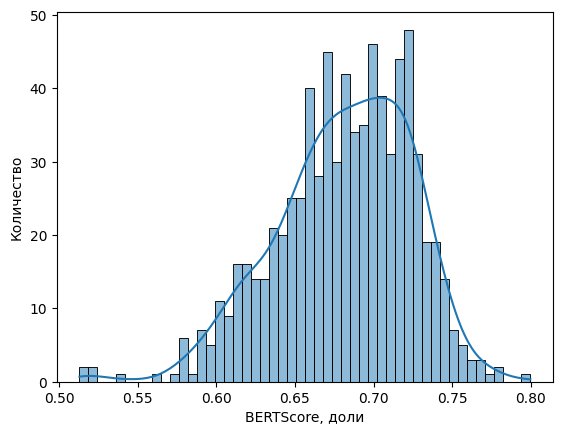

In [ ]:
sns.histplot(F1.detach().cpu().numpy(), bins=50, kde=True)
plt.xlabel('BERTScore')
plt.ylabel("Count")
plt.show()

## Cosin Sim

In [ ]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

def calculate_cosine_similarity(references, generated):

    model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

    cosine_scores = []
    for ref, gen in zip(references, generated):
        ref_embedding = model.encode(ref, convert_to_tensor=True)
        gen_embedding = model.encode(gen, convert_to_tensor=True)
        cosine_score = util.pytorch_cos_sim(ref_embedding, gen_embedding).item()
        cosine_scores.append(cosine_score)
    return cosine_scores

cosine_scores = calculate_cosine_similarity(references, generated)
print("Cosine Similarity Scores:", np.mean(cosine_scores))


Cosine Similarity Scores: 0.7630147335841199


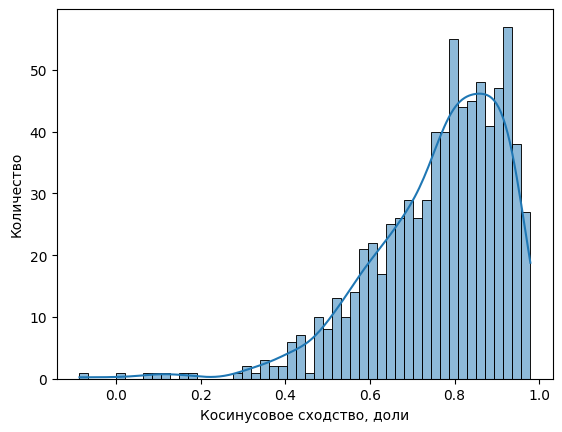

In [ ]:
sns.histplot(cosine_scores, bins=50, kde=True)
plt.xlabel('Cosine Similarity Scores')
plt.ylabel("Count")
plt.show()

In [ ]:
def evaluate_holdout(
    data,
    db_path=os.path.join(get_project_path(), "db", "intfloat_multilingual-e5-large"),
    model_name="intfloat/multilingual-e5-large",
    question_col="Request",
    answer_col="Right answer ",
    source_col="source",
    out_csv="holdout_metrics.csv",
):
    """Evaluate RAG pipeline in holdout mode for each question.

    The function removes the source document of each question from the index,
    runs the RAG pipeline without this document and collects accuracy,
    BERTScore and cosine similarity metrics. Results are saved to CSV.
    """
    embeddings = HuggingFaceEmbeddings(model_name=model_name)
    vector_store = FAISS.load_local(db_path, embeddings, allow_dangerous_deserialization=True)

    openai_client = OpenAI(base_url=os.environ["OPENAI_API_BASE"])

    questions = data[question_col].tolist()
    references = data[answer_col].tolist()
    sources = data[source_col].tolist()

    generated_answers = []
    for question, src in zip(questions, sources):
        retriever = vector_store.as_retriever(search_type="mmr", search_kwargs={"k":5, "lambda_mult":0.45, "fetch_k":50})
        docs = retriever.get_relevant_documents(question)
        docs = [d for d in docs if d.metadata.get("source") != src][:5]
        context = "

".join(d.page_content for d in docs)

        prompt = f"Вопрос: {question}\n\nКонтекст:\n{context}\n\nОтвет:"
        response = openai_client.chat.completions.create(
            model="openai/gpt-4o-mini",
            messages=[{"role":"user","content":prompt}],
            temperature=0.2,
            max_tokens=512,
        )
        generated_answers.append(response.choices[0].message.content.strip())

    accuracy = classify_responses(questions, references, generated_answers)
    P, R, F1 = scorer.score(generated_answers, references)
    cosine_scores = calculate_cosine_similarity(references, generated_answers)

    results_df = pd.DataFrame({
        "question": questions,
        "reference": references,
        "generated": generated_answers,
        "accuracy": accuracy,
        "bertscore_f1": F1.tolist(),
        "cosine_similarity": cosine_scores,
    })
    results_df.to_csv(out_csv, index=False)

    metrics = {
        "accuracy": float(np.mean(accuracy)),
        "bert_f1": float(torch.mean(F1)),
        "cosine_similarity": float(np.mean(cosine_scores)),
    }
    return metrics, results_df


In [ ]:
metrics, holdout_df = evaluate_holdout(
    data,
    out_csv=os.path.join(get_project_path(), "notebooks", "holdout_metrics.csv"),
)
metrics
